# NJ Census data – EDA

In [7]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Connect to DuckDB database
db_path = '../data/db/nj_pipeline.duckdb'
conn = duckdb.connect(db_path)

# Check if census_acs table exists (fix: use table_name instead of name)
tables = conn.execute("SELECT table_name FROM information_schema.tables WHERE table_schema = 'main'").fetchall()
table_names = [t[0] for t in tables]

if 'census_acs' not in table_names:
    print("Loading census data from CSV files...")
    
    # Load CSV files into DuckDB
    csv_files = {
        'places': 'data/census_acs_places_2023.csv',
        'zctas': 'data/census_acs_zctas_2023.csv',
        'zctas_all': 'data/census_acs_zctas_all_years.csv'
    }
    
    # Check which files exist and load them
    dfs = []
    for name, path in csv_files.items():
        if Path(path).exists():
            print(f"  Loading {name} from {path}...")
            df_temp = pd.read_csv(path)
            dfs.append(df_temp)
            print(f"    Loaded {len(df_temp)} rows")
    
    if dfs:
        # Combine all dataframes
        df_combined = pd.concat(dfs, ignore_index=True)
        
        # Create the census_acs table in DuckDB
        conn.execute("CREATE TABLE IF NOT EXISTS census_acs AS SELECT * FROM df_combined")
        print(f"\n✓ Created census_acs table with {len(df_combined)} total rows")
    else:
        print("\n✗ No CSV files found. Run the pipeline first:")
        print("  python -m pipeline.run_all --only census_acs")
        conn.close()
        raise FileNotFoundError("Census CSV files not found")

# Query the data
df = conn.execute("SELECT * FROM census_acs").df()
conn.close()

# Display summary
print(f"\nLoaded {len(df):,} rows and {len(df.columns)} columns from census_acs table")
df.head()

,geoid,NAME,geo_type,state_fips,place_fips,zcta,acs_year,pop_total,age_median,race_white,...,unemployment_rate_acs,pct_bachelors_plus,homeownership_rate,vacancy_rate,rent_burden_30plus_pct,rent_burden_severe_pct,avg_commute_minutes,pct_transit_commute,pct_wfh,diversity_index
0,3412580,"Chester borough, New Jersey",place,34,12580,None,2012,1558,41.4,1381,...,7.28,54.05,74.87,6.23,48.57,32.14,32.3,5.46,10.52,0.1974
1,3475620,"Ventnor City city, New Jersey",place,34,75620,None,2012,10785,45.9,8329,...,10.48,27.25,62.80,42.85,64.81,30.65,23.8,13.69,2.21,0.3628
2,3448480,"Mountain Lakes borough, New Jersey",place,34,48480,None,2012,4206,43.4,3723,...,8.49,86.33,95.15,4.70,66.67,47.62,32.2,9.46,12.15,0.2070
3,3407360,"Brass Castle CDP, New Jersey",place,34,07360,None,2012,1559,46.1,1550,...,10.24,29.55,94.09,0.00,54.29,0.00,34.2,0.00,4.40,0.0115
4,3476010,"Villas CDP, New Jersey",place,34,76010,None,2012,9410,38.8,8749,...,12.98,11.28,76.23,30.70,51.43,20.49,24.9,2.64,0.34,0.1297


In [17]:
# Quartile Analysis for geoid 3482570
import numpy as np

target_geoid = '3482570'

# Get the most recent year data for places only
latest_year = df[df['geo_type'] == 'place']['acs_year'].max()
places_df = df[(df['geo_type'] == 'place') & (df['acs_year'] == latest_year)].copy()

# Find target place
target_place = places_df[places_df['geoid'] == target_geoid]

if target_place.empty:
    print(f"⚠️  GEOID {target_geoid} not found in the data")
else:
    place_name = target_place['NAME'].values[0]
    print(f"📍 Analyzing: {place_name} (GEOID: {target_geoid})")
    print(f"📊 Comparing against {len(places_df)-1} other NJ places (Year: {latest_year})\n")
    print("="*80)
    
    # Define key metrics to analyze
    metrics = {
        'Demographics': [
            ('pop_total', 'Total Population', False),
            ('age_median', 'Median Age', False),
            ('diversity_index', 'Diversity Index', False),
        ],
        'Economics': [
            ('income_median_hh', 'Median Household Income ($)', False),
            ('income_per_capita', 'Per Capita Income ($)', False),
            ('poverty_rate', 'Poverty Rate (%)', True),
            ('gini_index', 'Income Inequality (Gini)', True),
        ],
        'Housing': [
            ('home_value_median', 'Median Home Value ($)', False),
            ('gross_rent_median', 'Median Rent ($/mo)', False),
            ('homeownership_rate', 'Homeownership Rate (%)', False),
            ('vacancy_rate', 'Vacancy Rate (%)', True),
            ('rent_burden_30plus_pct', 'Rent Burden 30%+ (%)', True),
        ],
        'Education & Employment': [
            ('pct_bachelors_plus', "Bachelor's Degree+ (%)", False),
            ('unemployment_rate_acs', 'Unemployment Rate (%)', True),
        ],
        'Transportation': [
            ('avg_commute_minutes', 'Avg Commute (minutes)', True),
            ('pct_transit_commute', 'Public Transit Use (%)', False),
            ('pct_wfh', 'Work From Home (%)', False),
        ],
    }
    
    # Calculate quartiles and rankings
    results = []
    
    for category, metric_list in metrics.items():
        for col, label, lower_is_better in metric_list:
            if col not in places_df.columns:
                continue
                
            # Get valid data (non-null)
            valid_data = places_df[places_df[col].notna()][col]
            
            if len(valid_data) == 0:
                continue
            
            target_val = target_place[col].values[0]
            
            if pd.isna(target_val):
                results.append({
                    'Category': category,
                    'Metric': label,
                    'Value': 'N/A',
                    'Quartile': 'N/A',
                    'Percentile': 'N/A',
                    'Rank': 'N/A',
                    'Total': len(valid_data),
                    'Lower_Is_Better': lower_is_better
                })
                continue
            
            # Calculate quartile
            q1, q2, q3 = np.percentile(valid_data, [25, 50, 75])
            
            if target_val <= q1:
                quartile = 'Q1 (Bottom 25%)'
            elif target_val <= q2:
                quartile = 'Q2 (25-50%)'
            elif target_val <= q3:
                quartile = 'Q3 (50-75%)'
            else:
                quartile = 'Q4 (Top 25%)'
            
            # Calculate percentile
            percentile = (valid_data < target_val).sum() / len(valid_data) * 100
            
            # Calculate rank (1 = best)
            if lower_is_better:
                rank = (valid_data < target_val).sum() + 1
            else:
                rank = (valid_data > target_val).sum() + 1
            
            results.append({
                'Category': category,
                'Metric': label,
                'Value': target_val,
                'Quartile': quartile,
                'Percentile': f'{percentile:.1f}%',
                'Rank': f'{rank}/{len(valid_data)}',
                'Total': len(valid_data),
                'Lower_Is_Better': lower_is_better,
                'Q1': q1,
                'Q2': q2,
                'Q3': q3,
            })
    
    # Display results table
    results_df = pd.DataFrame(results)
    
    for category in metrics.keys():
        cat_df = results_df[results_df['Category'] == category]
        if not cat_df.empty:
            print(f"\n{category.upper()}")
            print("-" * 80)
            for _, row in cat_df.iterrows():
                if isinstance(row['Value'], str):
                    print(f"  {row['Metric']:<40} {row['Value']}")
                else:
                    # Format value
                    if row['Value'] >= 1000:
                        val_str = f"${row['Value']:,.0f}" if '$' in row['Metric'] else f"{row['Value']:,.0f}"
                    else:
                        val_str = f"{row['Value']:.1f}"
                    
                    print(f"  {row['Metric']:<40} {val_str:<15} {row['Quartile']:<20} Rank: {row['Rank']}")
    
    print("\n" + "="*80)

📍 Analyzing: Wood-Ridge borough, New Jersey (GEOID: 3482570)
📊 Comparing against 699 other NJ places (Year: 2023)


DEMOGRAPHICS
--------------------------------------------------------------------------------
  Total Population                         10,094          Q4 (Top 25%)         Rank: 152/700
  Median Age                               39.7            Q2 (25-50%)          Rank: 489/698
  Diversity Index                          0.6             Q4 (Top 25%)         Rank: 109/700

ECONOMICS
--------------------------------------------------------------------------------
  Median Household Income ($)              $131,412        Q3 (50-75%)          Rank: 186/667
  Per Capita Income ($)                    $66,404         Q3 (50-75%)          Rank: 186/698
  Poverty Rate (%)                         6.5             Q3 (50-75%)          Rank: 393/694
  Income Inequality (Gini)                 0.4             Q3 (50-75%)          Rank: 420/691

HOUSING
-------------------------------

In [10]:
# zcta level df
nj_zcta_df = df[df['geo_type'] == 'zcta'].copy()


# places level df
nj_places_df = df[df['geo_type'] == 'place'].copy()


In [15]:
# filter to max acs_year only
nj_zcta_df = nj_zcta_df[nj_zcta_df['acs_year'] == 2023]
nj_places_df = nj_places_df[nj_places_df['acs_year'] == 2023]

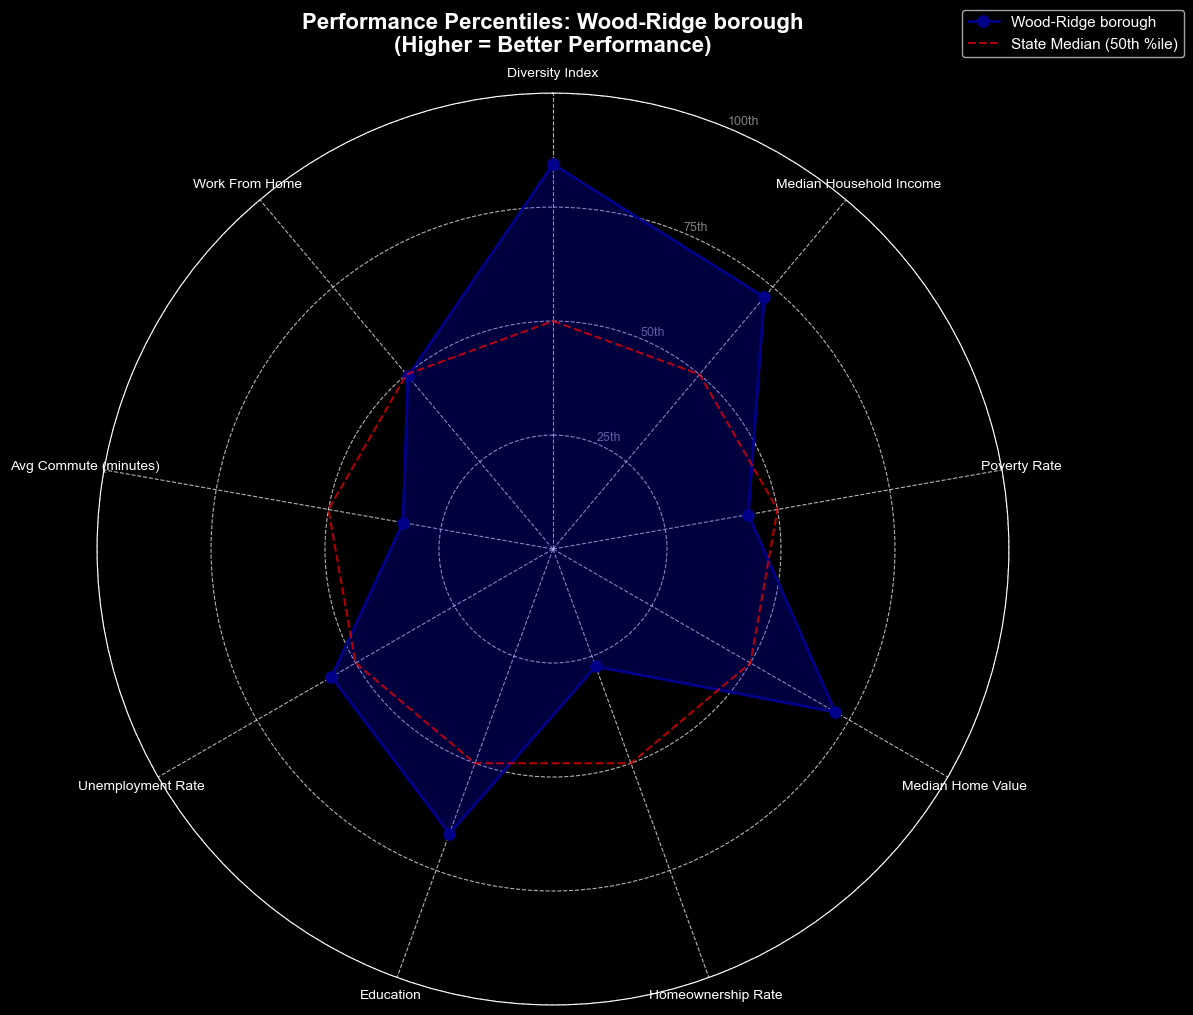

In [26]:
# Radar Chart: Performance Percentiles
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for radar chart
radar_data = []
for _, row in viz_df_filtered.iterrows():
    metric_name = row['Metric'].replace("Bachelor's Degree+ (%)", 'Education')
    metric_name = metric_name.replace(' ($)', '').replace(' (%)', '')
    percentile_val = float(row['Percentile'].rstrip('%'))

    # Invert if lower is better
    if row['Lower_Is_Better']:
        percentile_val = 100 - percentile_val

    radar_data.append((metric_name, percentile_val))

# Create radar chart
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='polar')

# Prepare data
labels = [item[0][:25] for item in radar_data]  # Truncate long labels
values = [item[1] for item in radar_data]

# Number of variables
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# Complete the circle
values += values[:1]
angles += angles[:1]

# Plot
ax.plot(angles, values, 'o-', linewidth=2, color='darkblue', markersize=8, label=place_name.split(',')[0])
ax.fill(angles, values, alpha=0.25, color='blue')

# Add median reference line
median_values = [50] * len(angles)
ax.plot(angles, median_values, '--', linewidth=1.5, color='red', alpha=0.7, label='State Median (50th %ile)')

# Styling
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=10)
ax.set_ylim(0, 100)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(['25th', '50th', '75th', '100th'], size=9, color='gray')
ax.grid(True, linestyle='--', alpha=0.7)

# Add title and legend
plt.title(f'Performance Percentiles: {place_name.split(",")[0]}\n(Higher = Better Performance)',
         size=16, fontweight='bold', pad=30)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=11)

plt.tight_layout()
plt.show()



In [30]:
# Direct Comparison: Two Places
compare_geoid = '3430420'  #


# Get both places
place1 = places_df[places_df['geoid'] == target_geoid].iloc[0]
place2 = places_df[places_df['geoid'] == compare_geoid]

if place2.empty:
    print(f"⚠️  GEOID {compare_geoid} not found in the data")
else:
    place2 = place2.iloc[0]
    name1 = place1['NAME'].split(',')[0]
    name2 = place2['NAME'].split(',')[0]
    
    print(f"{'='*90}")
    print(f"SIDE-BY-SIDE COMPARISON")
    print(f"{'='*90}")
    print(f"{'Metric':<40} {name1:<22} {name2:<22}")
    print(f"{'-'*90}")
    
    # Compare key metrics
    comparison_metrics = [
        ('pop_total', 'Total Population', False),
        ('age_median', 'Median Age', False),
        ('diversity_index', 'Diversity Index', False),
        ('income_median_hh', 'Median Household Income', False),
        ('poverty_rate', 'Poverty Rate (%)', True),
        ('home_value_median', 'Median Home Value', False),
        ('gross_rent_median', 'Median Rent', False),
        ('homeownership_rate', 'Homeownership Rate (%)', False),
        ('pct_bachelors_plus', "Bachelor's Degree+", False),
        ('unemployment_rate_acs', 'Unemployment Rate (%)', True),
        ('avg_commute_minutes', 'Avg Commute (min)', True),
        ('pct_transit_commute', 'Transit Use (%)', False),
        ('pct_wfh', 'Work From Home (%)', False),
    ]
    
    comparison_data = []
    
    for col, label, lower_is_better in comparison_metrics:
        if col in place1.index and col in place2.index:
            val1 = place1[col]
            val2 = place2[col]
            
            if pd.notna(val1) and pd.notna(val2):
                # Format values
                if val1 >= 1000 or val2 >= 1000:
                    if 'Income' in label or 'Value' in label or 'Rent' in label:
                        v1_str = f"${val1:,.0f}"
                        v2_str = f"${val2:,.0f}"
                    else:
                        v1_str = f"{val1:,.0f}"
                        v2_str = f"{val2:,.0f}"
                else:
                    v1_str = f"{val1:.1f}"
                    v2_str = f"{val2:.1f}"
                
                # Determine winner
                if lower_is_better:
                    winner = '✓' if val1 < val2 else ''
                    loser = '✓' if val2 < val1 else ''
                else:
                    winner = '✓' if val1 > val2 else ''
                    loser = '✓' if val2 > val1 else ''
                
                if val1 == val2:
                    winner = loser = '='
                
                print(f"{label:<40} {v1_str:<20} {winner:>1} {v2_str:<20} {loser:>1}")
                
                comparison_data.append({
                    'metric': label,
                    'col': col,
                    'val1': val1,
                    'val2': val2,
                    'lower_is_better': lower_is_better
                })
    
    print(f"{'='*90}\n")

SIDE-BY-SIDE COMPARISON
Metric                                   Wood-Ridge borough     Hasbrouck Heights borough
------------------------------------------------------------------------------------------
Total Population                         10,094                 12,067               ✓
Median Age                               39.7                   44.2                 ✓
Diversity Index                          0.6                  ✓ 0.5                   
Median Household Income                  $131,412             ✓ $118,670              
Poverty Rate (%)                         6.5                  ✓ 9.4                   
Median Home Value                        $532,900             ✓ $508,500              
Median Rent                              $1,886               ✓ $1,605                
Homeownership Rate (%)                   64.6                   70.3                 ✓
Bachelor's Degree+                       53.5                 ✓ 42.2                  
Unemployment

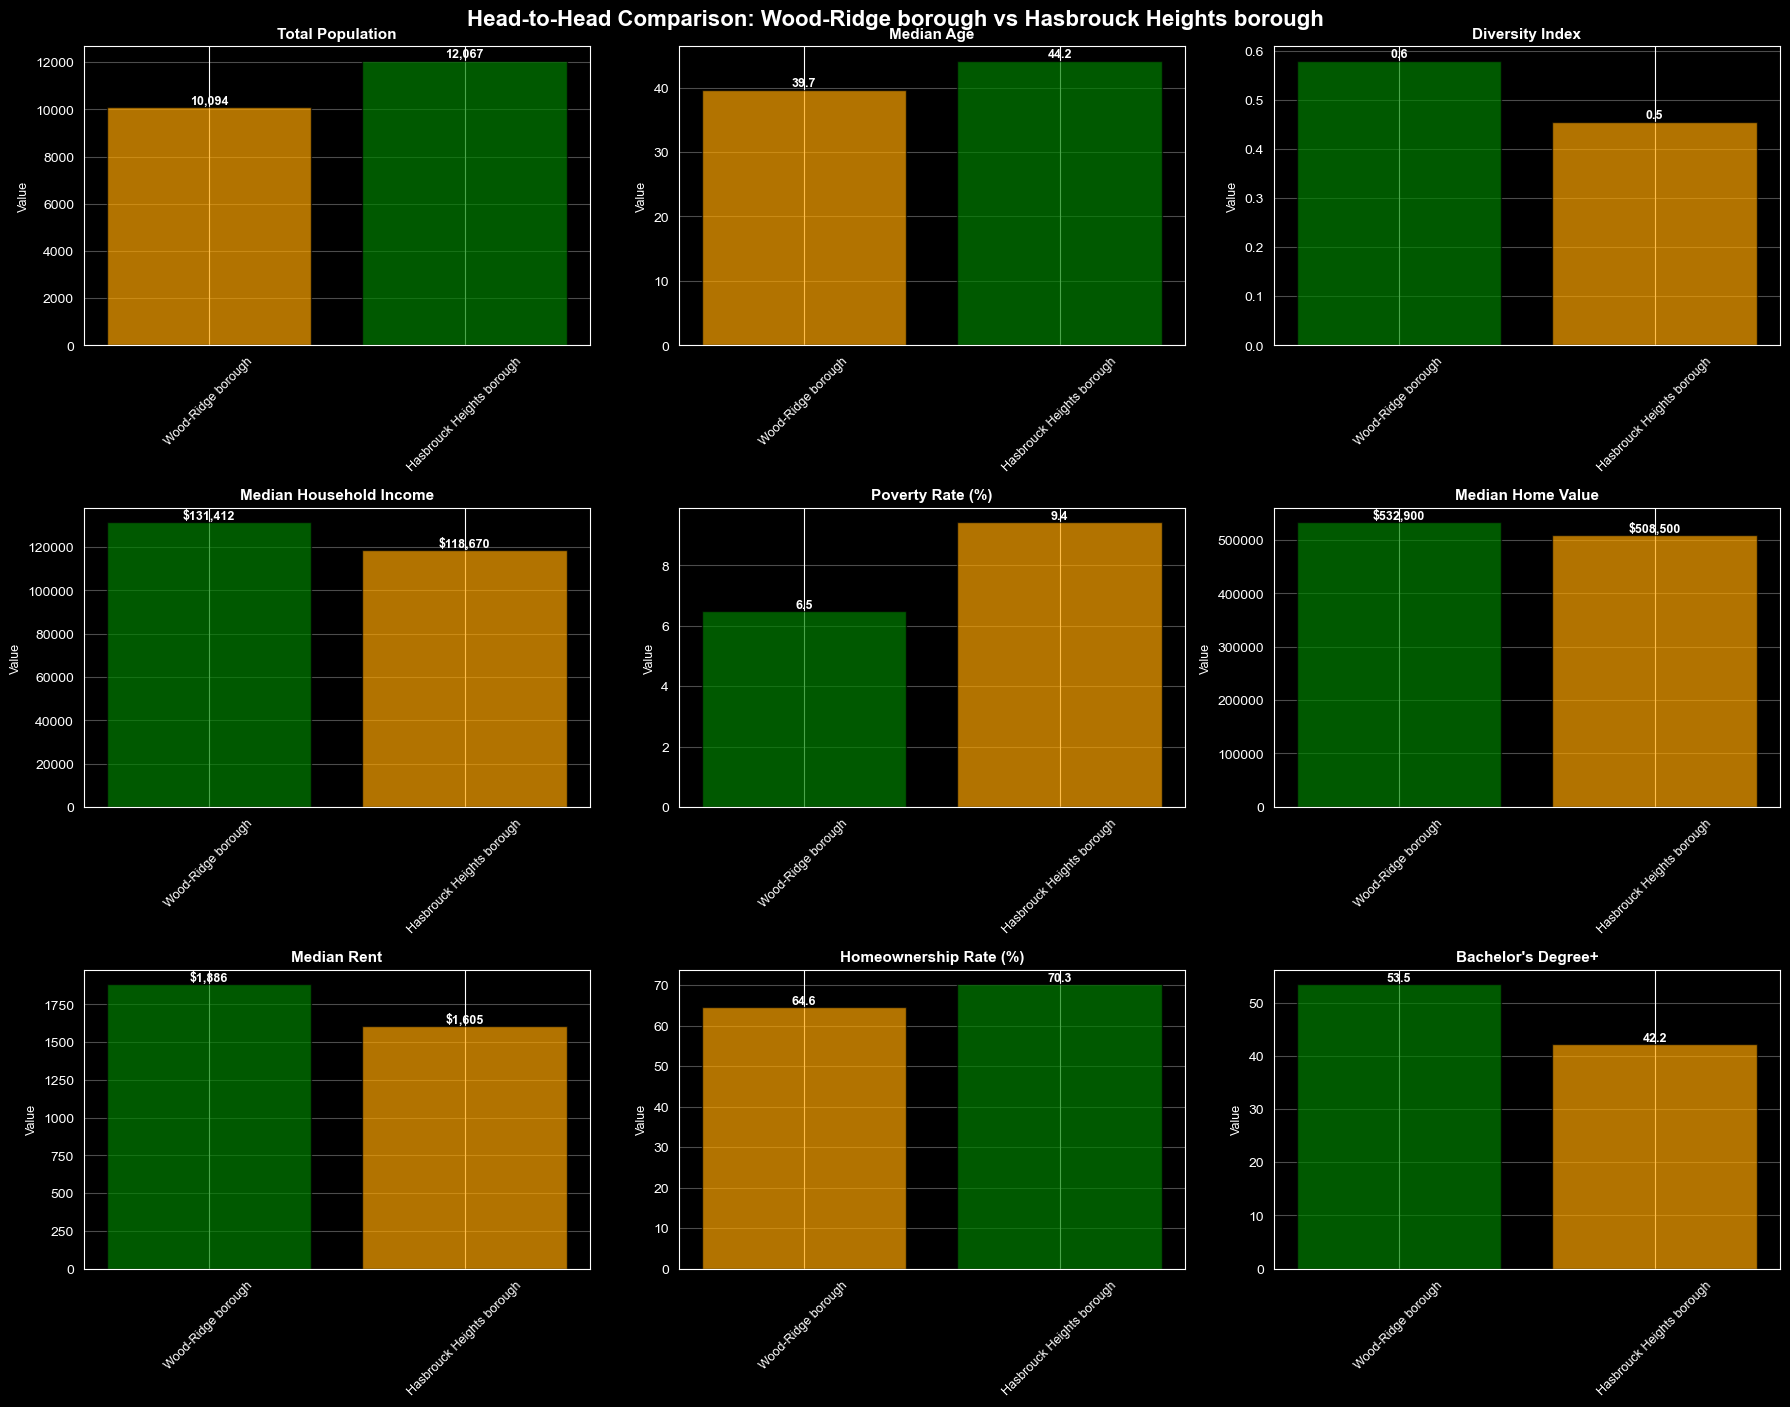

In [32]:
# Comparison Visualization: Bar Charts
if len(comparison_data) > 0:
    # Create bar chart comparison
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    axes = axes.flatten()
    
    # Select top 9 metrics for visualization
    viz_metrics = comparison_data[:9]
    
    for idx, item in enumerate(viz_metrics):
        ax = axes[idx]
        metric = item['metric']
        v1 = item['val1']
        v2 = item['val2']
        lower_is_better = item['lower_is_better']
        
        # Determine colors (green = better, orange = worse)
        if lower_is_better:
            color1 = 'green' if v1 < v2 else 'orange'
            color2 = 'green' if v2 < v1 else 'orange'
        else:
            color1 = 'green' if v1 > v2 else 'orange'
            color2 = 'green' if v2 > v1 else 'orange'
        
        if v1 == v2:
            color1 = color2 = 'gray'
        
        # Bar chart
        bars = ax.bar([name1, name2], [v1, v2], color=[color1, color2], alpha=0.7, edgecolor='black')
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            if height >= 1000:
                if '$' in metric or 'Income' in metric or 'Value' in metric or 'Rent' in metric:
                    label = f'${height:,.0f}'
                else:
                    label = f'{height:,.0f}'
            else:
                label = f'{height:.1f}'
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   label, ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.set_title(metric, fontsize=11, fontweight='bold')
        ax.set_ylabel('Value', fontsize=9)
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle(f'Head-to-Head Comparison: {name1} vs {name2}', 
                fontsize=16, fontweight='bold', y=1.002)
    plt.show()
    
